# Phase 2 - Exploration des donnees

Ce notebook sert d'abord a explorer le dataset `data/dataset.csv`. Les blocs d'analyse et d'interpretation seront ajoutes apres execution des cellules, a partir des resultats observes.

## 1. Setup & chargement des donnees

In [2]:
# Import des bibliotheques necessaires.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration globale des graphiques.
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Couleurs constantes pour la variable cible.
CLASS_COLORS = {0: '#1f77b4', 1: '#d62728'}
CLASS_LABELS = {0: 'Normal (0)', 1: 'Shock (1)'}
CLASS_LABEL_COLORS = {'Normal (0)': '#1f77b4', 'Shock (1)': '#d62728'}

In [10]:
# Chargement du dataset.
import os

current_path = os.getcwd()

data_path = Path(current_path) / 'modeling' / 'data' / 'dataset.csv'

if not data_path.exists():
    data_path = Path('data') / 'dataset.csv'

df = pd.read_csv(data_path)

# Apercu general du dataset.
print('Shape:', df.shape)
display(df.dtypes)
display(df.head())

Shape: (10603, 24)


country                      str
year                       int64
current_account_pct      float64
debt_service_pct         float64
domestic_credit_pct      float64
external_debt_pct        float64
fdi_inflows              float64
fx_reserves_months       float64
gdp_growth               float64
gdp_per_capita           float64
gni_per_capita_growth    float64
gov_expenditure          float64
govt_debt_pct_gdp        float64
inflation                float64
trade_openness           float64
unemployment             float64
country_name                 str
region                       str
income_group                 str
lending_type                 str
gdp_growth_lag1          float64
gdp_growth_delta         float64
is_crisis_decade             str
gdp_shock                  int64
dtype: object

,country,year,current_account_pct,debt_service_pct,domestic_credit_pct,external_debt_pct,fdi_inflows,fx_reserves_months,gdp_growth,gdp_per_capita,...,trade_openness,unemployment,country_name,region,income_group,lending_type,gdp_growth_lag1,gdp_growth_delta,is_crisis_decade,gdp_shock
0,ABW,1988,-7.425094,NaN,NaN,NaN,2.055486,3.384498,18.648649,22468.507120,...,NaN,NaN,Aruba,Latin America & Caribbean,High income,Not classified,16.078431,2.570217,1980s,0
1,ABW,1989,-6.714859,NaN,NaN,NaN,0.186908,2.921822,12.129841,24730.396448,...,NaN,NaN,Aruba,Latin America & Caribbean,High income,Not classified,18.648649,-6.518808,1980s,0
2,ABW,1990,-20.679328,NaN,NaN,NaN,17.063550,2.217400,3.961402,24763.653810,...,NaN,NaN,Aruba,Latin America & Caribbean,High income,Not classified,12.129841,-8.168439,1990s,0
3,ABW,1991,-24.023062,NaN,NaN,NaN,21.185138,1.179546,7.962872,25460.363027,...,NaN,NaN,Aruba,Latin America & Caribbean,High income,Not classified,3.961402,4.001470,1990s,0
4,ABW,1992,4.568765,NaN,NaN,NaN,-3.857809,1.292875,5.882354,25743.445501,...,NaN,NaN,Aruba,Latin America & Caribbean,High income,Not classified,7.962872,-2.080518,1990s,0


In [11]:
# Definition des variables a explorer.
target = 'gdp_shock'

numeric_vars = [
    'gdp_growth', 'inflation', 'unemployment', 'gdp_per_capita',
    'external_debt_pct', 'trade_openness', 'fdi_inflows', 'gov_expenditure',
    'current_account_pct', 'fx_reserves_months', 'debt_service_pct',
    'gni_per_capita_growth', 'gdp_growth_lag1', 'gdp_growth_delta'
]

categorical_vars = ['region', 'income_group', 'lending_type', 'is_crisis_decade']

# Verification que les colonnes attendues existent bien.
expected_cols = numeric_vars + categorical_vars + [target]
missing_cols = [col for col in expected_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f'Colonnes attendues absentes du dataset: {missing_cols}')

print('Toutes les colonnes attendues sont presentes.')

Toutes les colonnes attendues sont presentes.


### Notes apres execution

- Le dataset contient 10 603 lignes et 24 colonnes.
- Chaque ligne correspond a une observation pays-annee. Les colonnes `country`, `country_name`, `region`, `income_group`, `lending_type` et `is_crisis_decade` sont categorielles.
- La majorite des variables explicatives economiques sont numeriques (`float64`). La cible `gdp_shock` est binaire et stockee en entier (`int64`).
- Les premieres lignes montrent deja des valeurs manquantes sur certaines variables macro-financieres, notamment `debt_service_pct`, `domestic_credit_pct`, `external_debt_pct`, `trade_openness` et `unemployment`.

## 2. Exploration de la qualite des donnees

In [12]:
# Nombre et pourcentage de valeurs manquantes par colonne.
missing_table = (
    df.isna().sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_pct=lambda x: 100 * x['missing_count'] / len(df))
    .sort_values('missing_pct', ascending=False)
)

display(missing_table)

,missing_count,missing_pct
domestic_credit_pct,9198,86.749033
govt_debt_pct_gdp,9030,85.164576
gov_expenditure,6256,59.002169
debt_service_pct,6096,57.493162
external_debt_pct,5363,50.580025
gni_per_capita_growth,5161,48.674903
unemployment,4832,45.572008
fx_reserves_months,4057,38.262756
current_account_pct,3444,32.481373
trade_openness,2424,22.861454


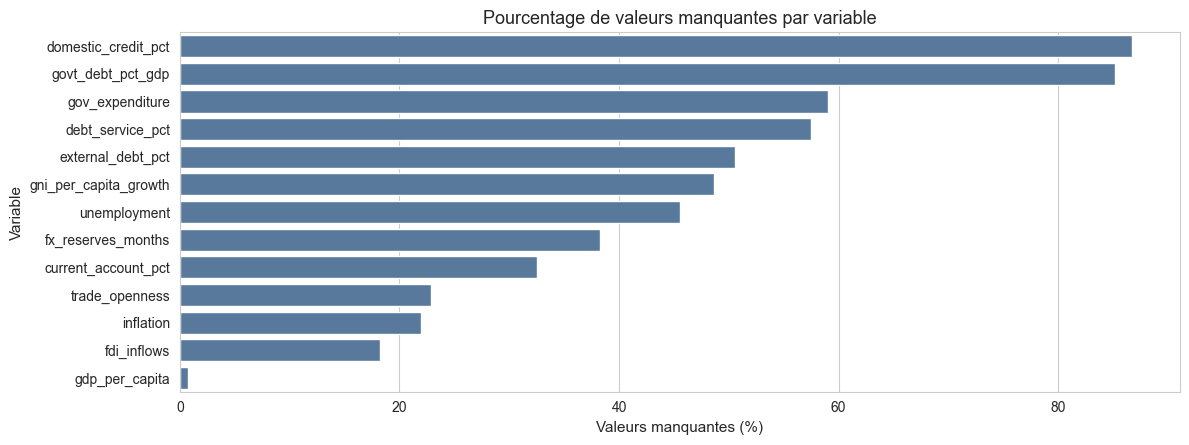

In [13]:
# Visualisation des valeurs manquantes les plus importantes.
missing_to_plot = missing_table[missing_table['missing_count'] > 0]

plt.figure(figsize=(12, max(4, 0.35 * len(missing_to_plot))))
sns.barplot(data=missing_to_plot.reset_index(), x='missing_pct', y='index', color='#4c78a8')
plt.title('Pourcentage de valeurs manquantes par variable')
plt.xlabel('Valeurs manquantes (%)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

In [14]:
# Recherche de doublons exacts.
duplicate_count = df.duplicated().sum()
print(f'Nombre de lignes dupliquees exactes: {duplicate_count}')

# Verification de l'unicite du couple pays-annee si les colonnes existent.
if {'country', 'year'}.issubset(df.columns):
    duplicated_country_year = df.duplicated(subset=['country', 'year']).sum()
    print(f'Nombre de doublons sur le couple country-year: {duplicated_country_year}')

Nombre de lignes dupliquees exactes: 0
Nombre de doublons sur le couple country-year: 0


### Notes apres execution

- Aucun doublon exact n'est present dans le dataset.
- Aucun doublon n'est detecte sur le couple `country-year`, ce qui confirme l'unicite des observations pays-annee.
- Les valeurs manquantes sont concentrees sur plusieurs variables macro-financieres: `domestic_credit_pct` (86.75%), `govt_debt_pct_gdp` (85.16%), `gov_expenditure` (59.00%), `debt_service_pct` (57.49%) et `external_debt_pct` (50.58%).
- Les variables de base liees a la cible (`gdp_growth`, `gdp_growth_lag1`, `gdp_growth_delta`) ne contiennent pas de valeurs manquantes dans ce dataset.

## 3. Exploration de la variable cible

,count,pct
gdp_shock,,
0,9724,91.71
1,879,8.29


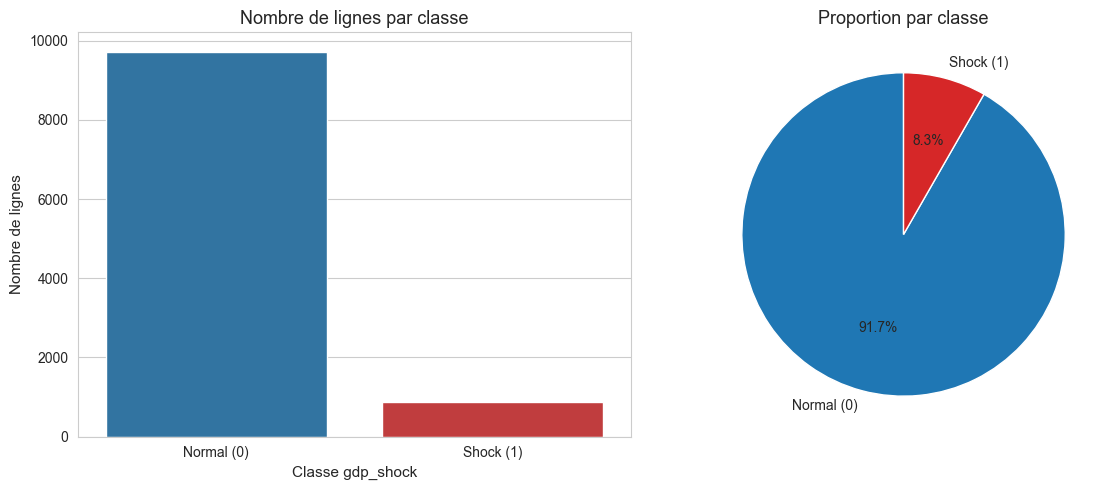

In [15]:
# Distribution de la variable cible.
class_counts = df[target].value_counts().sort_index()
class_pct = df[target].value_counts(normalize=True).sort_index() * 100
target_distribution = pd.DataFrame({'count': class_counts, 'pct': class_pct.round(2)})

display(target_distribution)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_plot = target_distribution.reset_index().rename(columns={'index': target})
target_plot['class_label'] = target_plot[target].map(CLASS_LABELS)

sns.barplot(
    data=target_plot,
    x='class_label',
    y='count',
    hue='class_label',
    palette=CLASS_LABEL_COLORS,
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Nombre de lignes par classe')
axes[0].set_xlabel('Classe gdp_shock')
axes[0].set_ylabel('Nombre de lignes')

axes[1].pie(
    class_counts.values,
    labels=[CLASS_LABELS.get(i, str(i)) for i in class_counts.index],
    autopct='%1.1f%%',
    colors=[CLASS_LABEL_COLORS.get(CLASS_LABELS.get(i), '#999999') for i in class_counts.index],
    startangle=90
)
axes[1].set_title('Proportion par classe')

plt.tight_layout()
plt.show()

,year,count,sum,mean,shock_rate_pct
0,1962,107,4,0.037383,3.738318
1,1963,112,12,0.107143,10.714286
2,1964,112,6,0.053571,5.357143
3,1965,112,8,0.071429,7.142857
4,1966,112,11,0.098214,9.821429
...,...,...,...,...,...
56,2018,210,5,0.023810,2.380952
57,2019,210,5,0.023810,2.380952
58,2020,210,128,0.609524,60.952381
59,2021,210,1,0.004762,0.476190


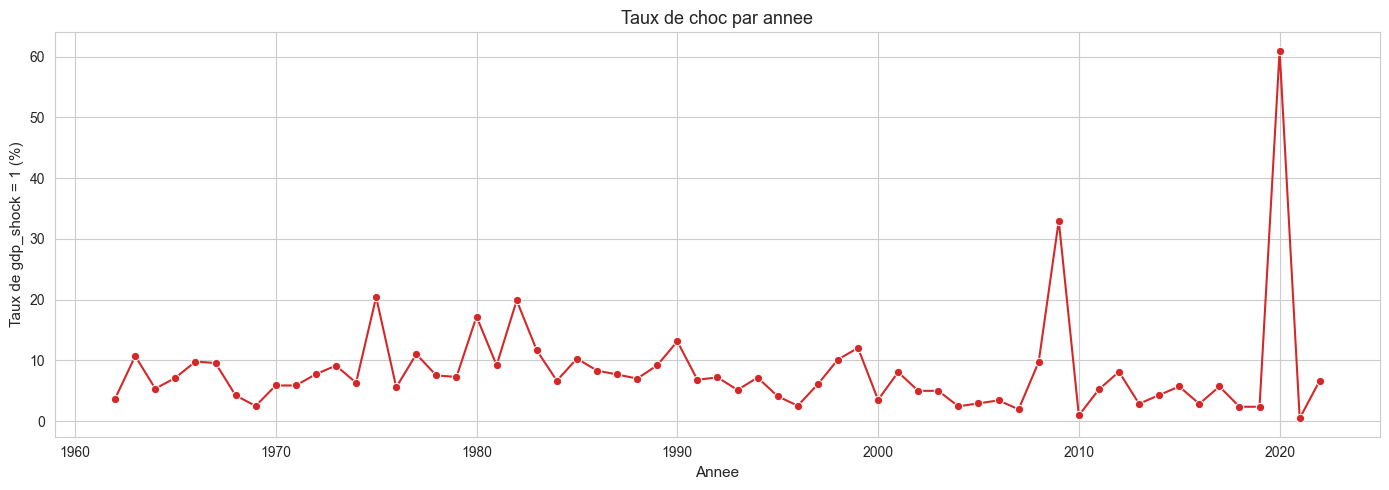

In [16]:
# Evolution du taux de choc par annee, si la colonne year existe.
if 'year' in df.columns:
    shock_by_year = (
        df.groupby('year')[target]
        .agg(['count', 'sum', 'mean'])
        .assign(shock_rate_pct=lambda x: 100 * x['mean'])
        .reset_index()
    )
    display(shock_by_year)

    plt.figure(figsize=(14, 5))
    sns.lineplot(data=shock_by_year, x='year', y='shock_rate_pct', marker='o', color='#d62728')
    plt.title('Taux de choc par annee')
    plt.xlabel('Annee')
    plt.ylabel('Taux de gdp_shock = 1 (%)')
    plt.tight_layout()
    plt.show()

,count,sum,mean,shock_rate_pct
is_crisis_decade,,,,
1960s,907,60,0.066152,6.615215
1970s,1391,122,0.087707,8.770669
1980s,1639,174,0.106162,10.616229
1990s,1918,142,0.074035,7.403545
2000s,2024,153,0.075593,7.559289
2010s,2095,85,0.040573,4.057279
2020s,629,143,0.227345,22.734499


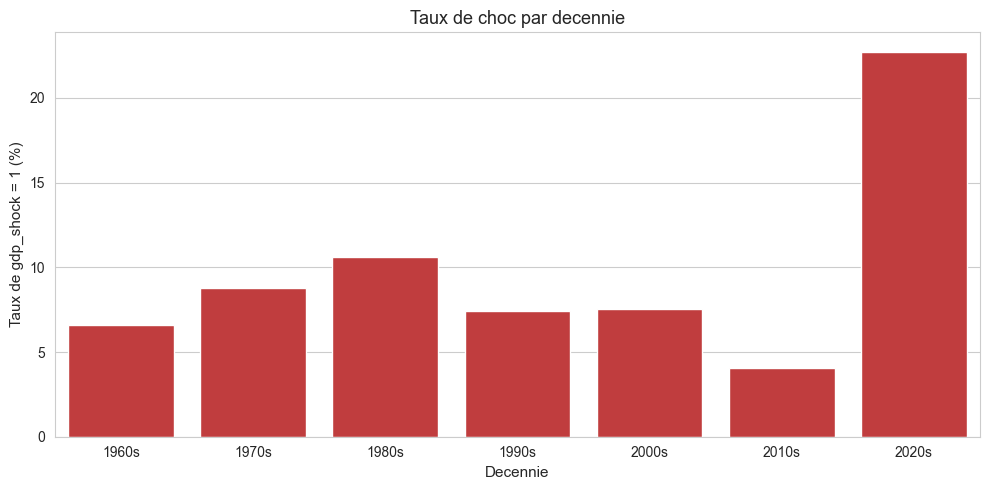

In [17]:
# Taux de choc par decennie si la colonne existe.
if 'is_crisis_decade' in df.columns:
    shock_by_decade = (
        df.groupby('is_crisis_decade')[target]
        .agg(['count', 'sum', 'mean'])
        .assign(shock_rate_pct=lambda x: 100 * x['mean'])
        .sort_index()
    )
    display(shock_by_decade)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=shock_by_decade.reset_index(), x='is_crisis_decade', y='shock_rate_pct', color='#d62728')
    plt.title('Taux de choc par decennie')
    plt.xlabel('Decennie')
    plt.ylabel('Taux de gdp_shock = 1 (%)')
    plt.tight_layout()
    plt.show()

### Notes apres execution

- La variable cible est fortement desequilibree: la classe 0 represente 91.7% des observations, contre 8.3% pour la classe 1.
- Sur l'evolution annuelle, l'annee 2020 ressort fortement avec 128 chocs sur 210 observations, soit 61.0%.
- Par decennie, les annees 2020 ont le taux de choc le plus eleve (22.7%). Les annees 1980 suivent avec 10.6%, puis les annees 1970 avec 8.8%.
- Le taux le plus faible par decennie est observe dans les annees 2010 (4.1%).

## 4. Exploration univariee des variables numeriques

In [18]:
# Statistiques descriptives des variables numeriques.
numeric_summary = df[numeric_vars].describe().T
numeric_summary['missing_count'] = df[numeric_vars].isna().sum()
numeric_summary['missing_pct'] = 100 * numeric_summary['missing_count'] / len(df)
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct
gdp_growth,10603.0,3.650857,6.800040,-64.047107,1.169158,3.786513,6.307230,149.972963,0,0.000000
inflation,8272.0,23.293065,331.625304,-17.640424,2.160545,4.934043,10.261861,23773.131774,2331,21.984344
unemployment,5771.0,8.073421,6.000957,0.100000,3.685000,6.365000,10.919500,38.800000,4832,45.572008
gdp_per_capita,10521.0,12441.944584,19250.712035,122.678901,1347.213064,3998.797292,16264.894039,214359.605826,82,0.773366
external_debt_pct,5240.0,60.436527,74.573150,0.000000,26.023280,43.305579,69.993746,1343.269962,5363,50.580025
trade_openness,8179.0,77.905932,53.364779,0.020999,44.669975,66.354988,96.590501,863.195099,2424,22.861454
fdi_inflows,8670.0,5.052233,36.877917,-391.555119,0.379617,1.569344,4.027168,1709.827224,1933,18.230689
gov_expenditure,4347.0,26.622044,19.101771,2.045768,17.029239,25.100040,34.039632,758.958242,6256,59.002169
current_account_pct,7159.0,-2.762381,12.515793,-147.997312,-6.975260,-2.879705,0.937123,311.746071,3444,32.481373
fx_reserves_months,6546.0,4.334482,4.489844,0.002215,1.827914,3.290999,5.309421,79.237218,4057,38.262756


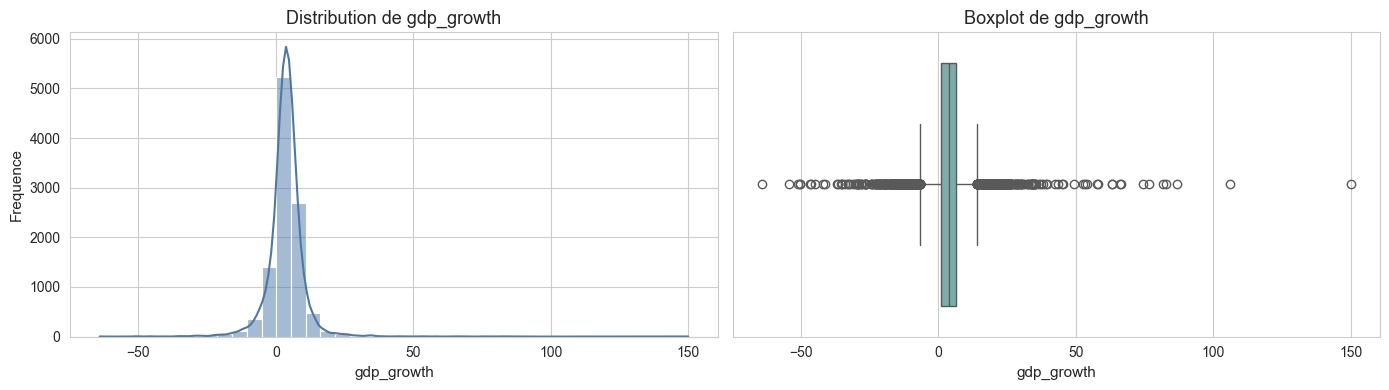

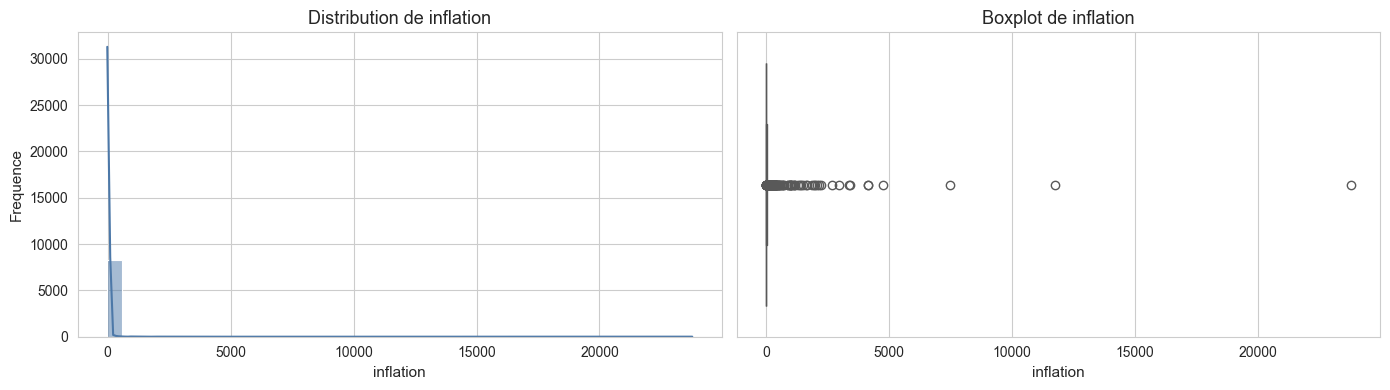

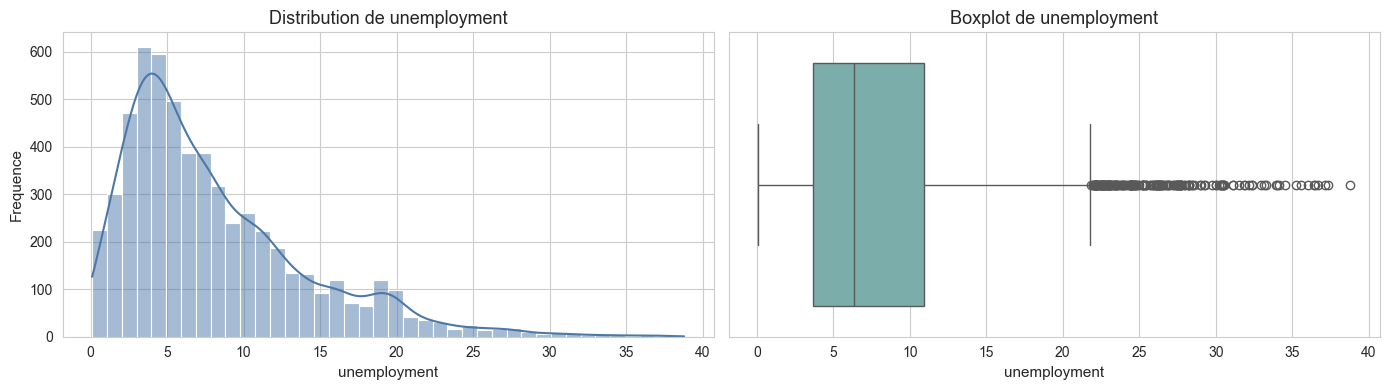

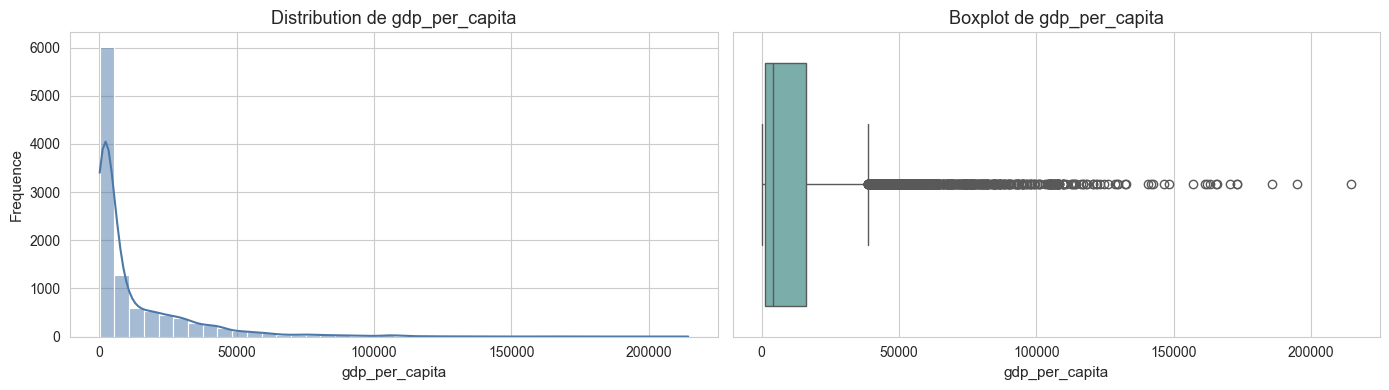

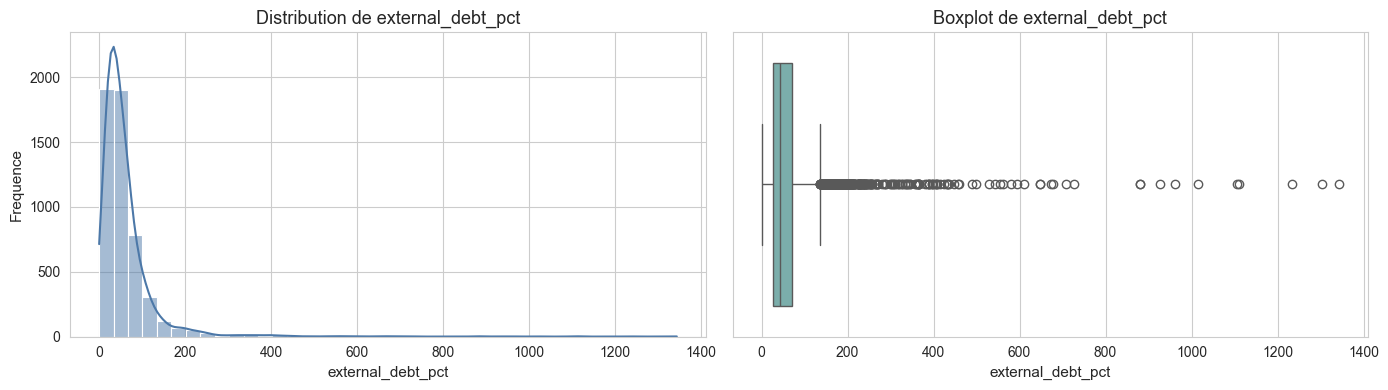

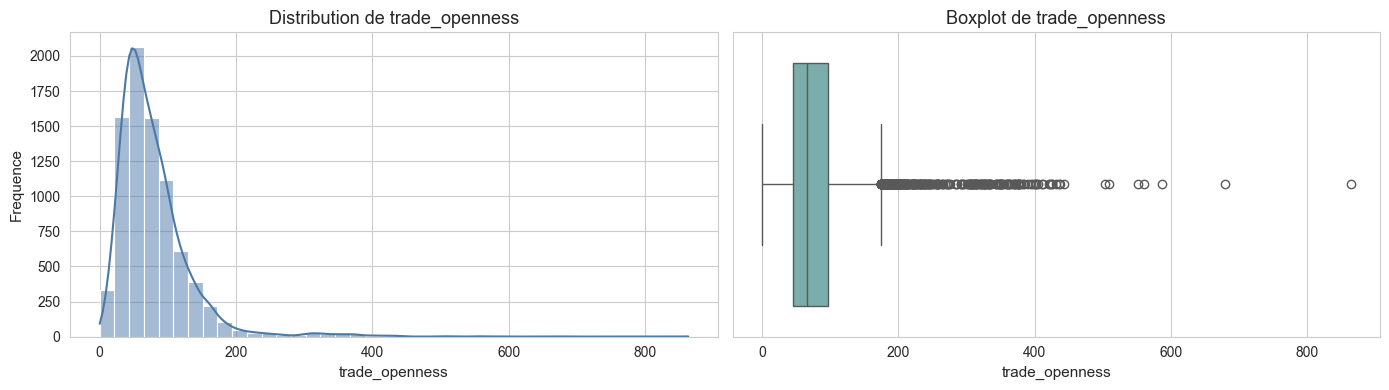

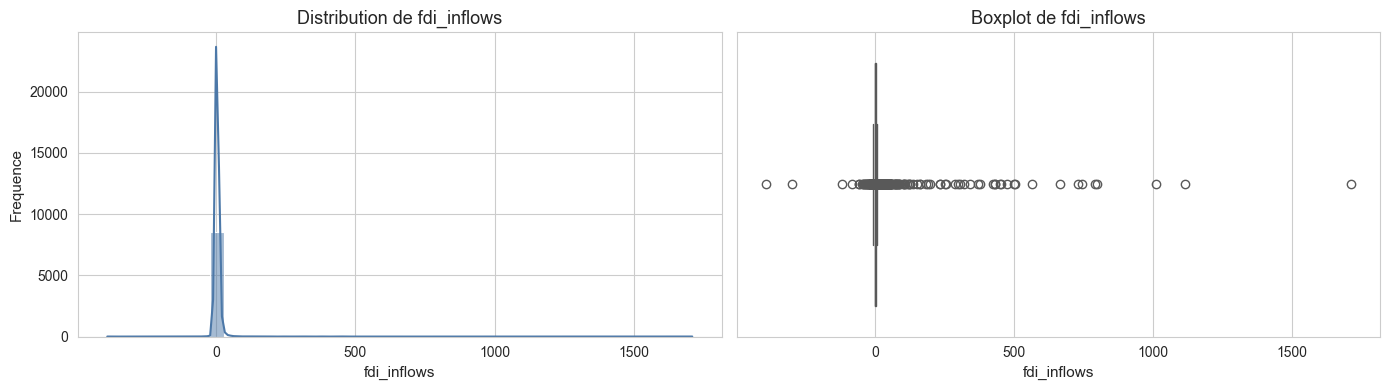

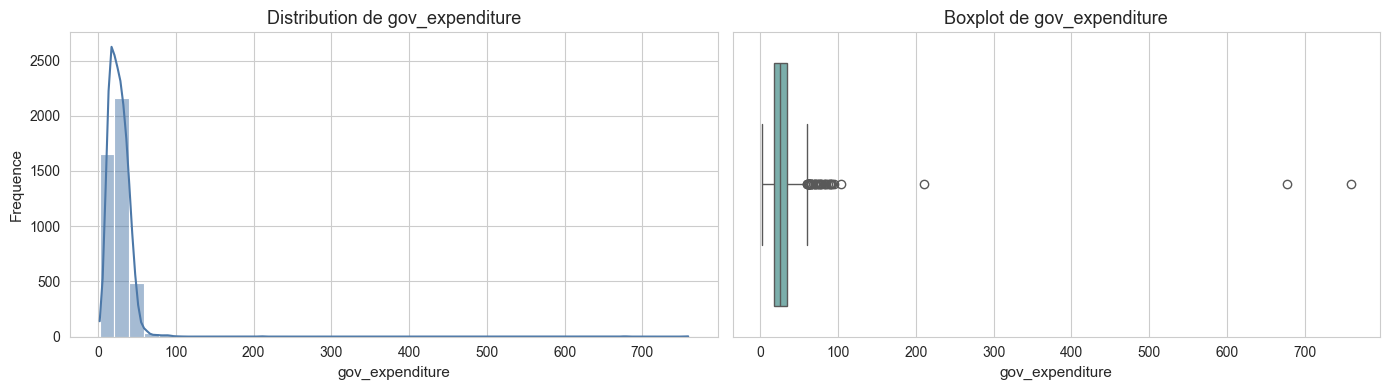

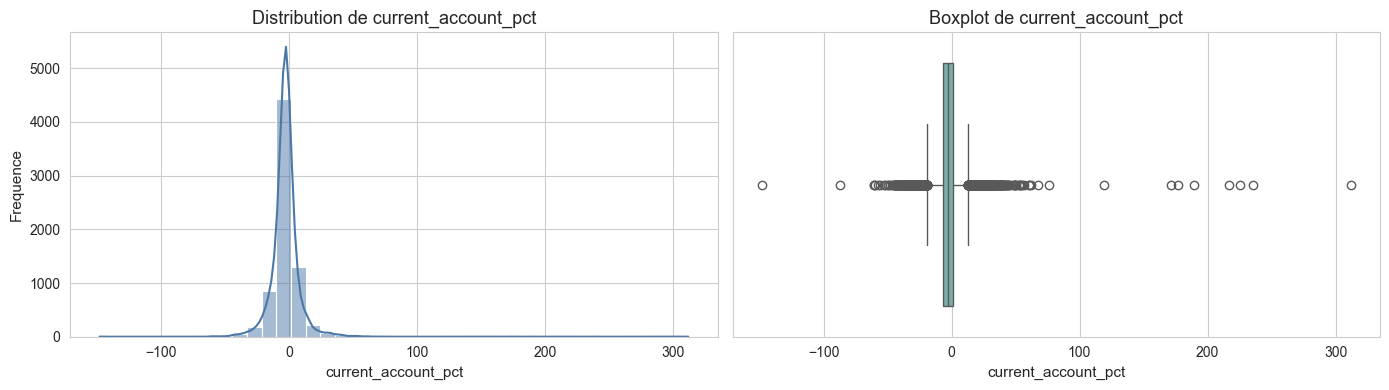

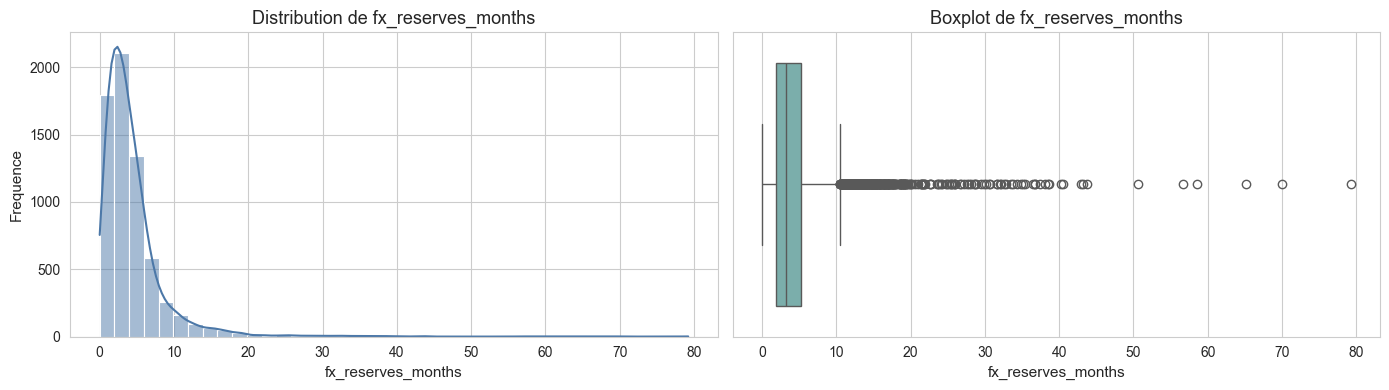

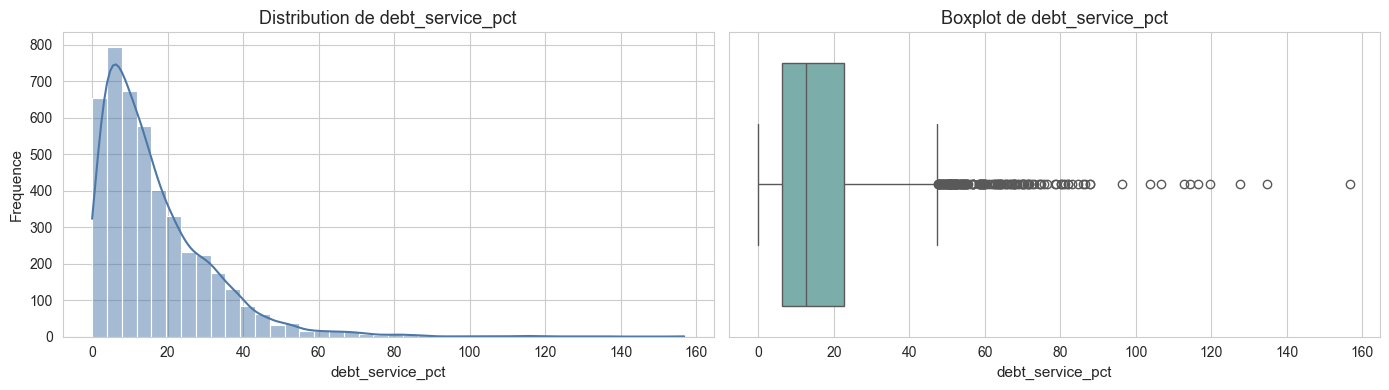

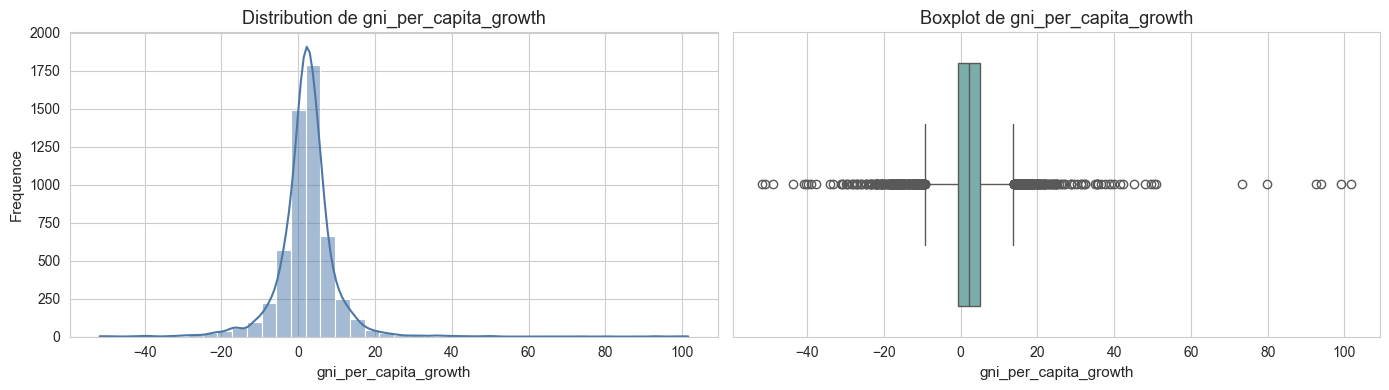

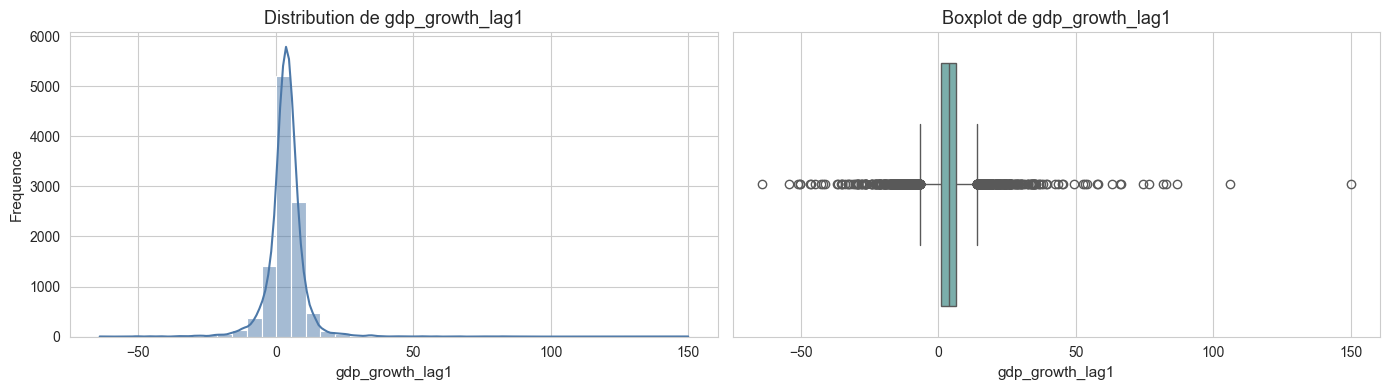

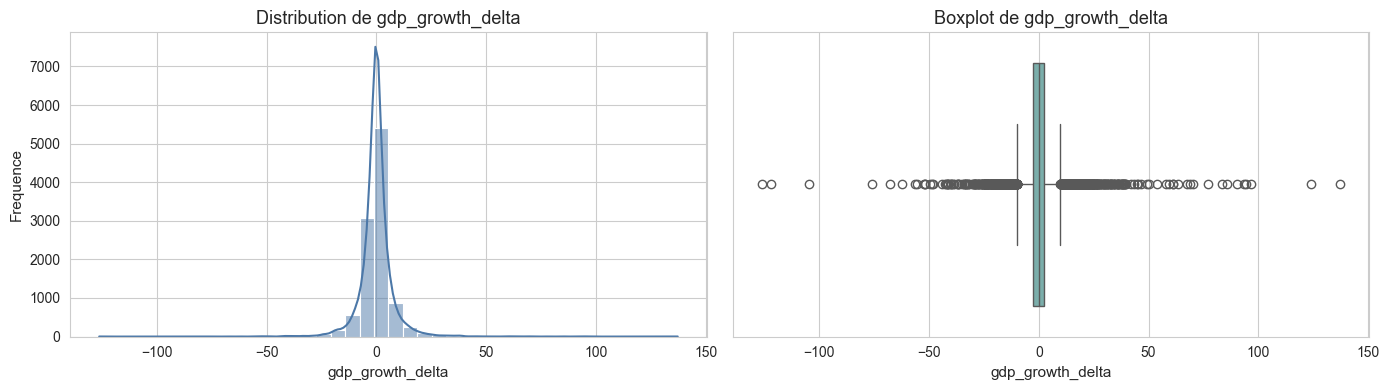

In [19]:
# Histogramme et boxplot pour chaque variable numerique.
for col in numeric_vars:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(data=df, x=col, kde=True, bins=40, color='#4c78a8', ax=axes[0])
    axes[0].set_title(f'Distribution de {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequence')

    sns.boxplot(data=df, x=col, color='#72b7b2', ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

### Notes apres execution

- Les valeurs manquantes sont importantes pour plusieurs variables: `domestic_credit_pct` (86.75%), `govt_debt_pct_gdp` (85.16%), `gov_expenditure` (59.00%), `debt_service_pct` (57.49%) et `external_debt_pct` (50.58%).
- D'autres variables ont aussi beaucoup de valeurs manquantes: `gni_per_capita_growth` (48.67%), `unemployment` (45.57%), `fx_reserves_months` (38.26%), `current_account_pct` (32.48%), `trade_openness` (22.86%), `inflation` (21.98%) et `fdi_inflows` (18.23%).
- `gdp_per_capita` a peu de valeurs manquantes (0.77%). Les variables utilisees pour la cible (`gdp_growth`, `gdp_growth_lag1`, `gdp_growth_delta`) ne presentent pas de valeurs manquantes dans ce dataset.
- Les boxplots montrent des valeurs extremes sur certaines variables. Les outliers connus sont reels: `current_account_pct` varie environ de -148 a +312, et `gdp_growth_delta` environ de -126 a +137.

## 5. Exploration univariee des variables categorielles

Variable: region


,count,pct
region,,
Sub-Saharan Africa,2633,24.832595
Europe & Central Asia,2450,23.106668
Latin America & Caribbean,2090,19.711402
East Asia & Pacific,1761,16.608507
"Middle East, North Africa, Afghanistan & Pakistan",1141,10.761105
South Asia,345,3.253796
North America,183,1.725927


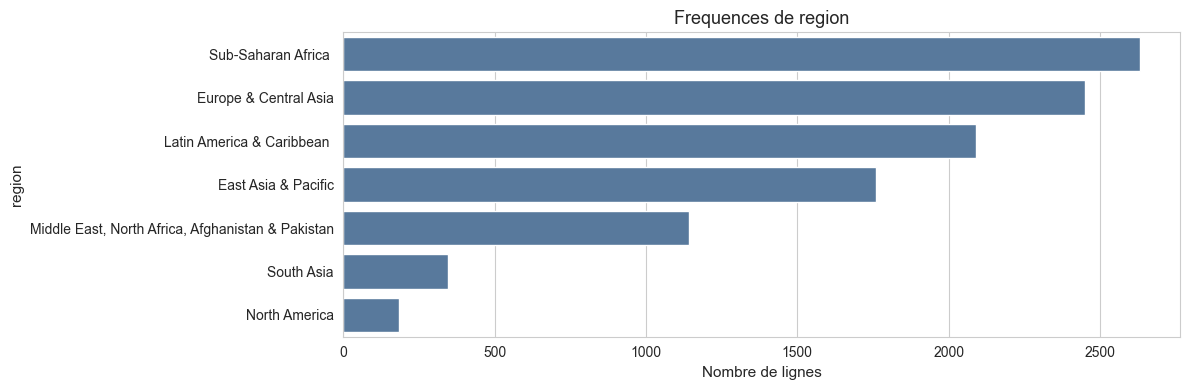

Modalites rares (< 1%) pour region:


,count,pct
region,,


Variable: income_group


,count,pct
income_group,,
High income,3979,37.527115
Upper middle income,2696,25.426766
Lower middle income,2580,24.332736
Low income,1227,11.572197
Not classified,121,1.141186


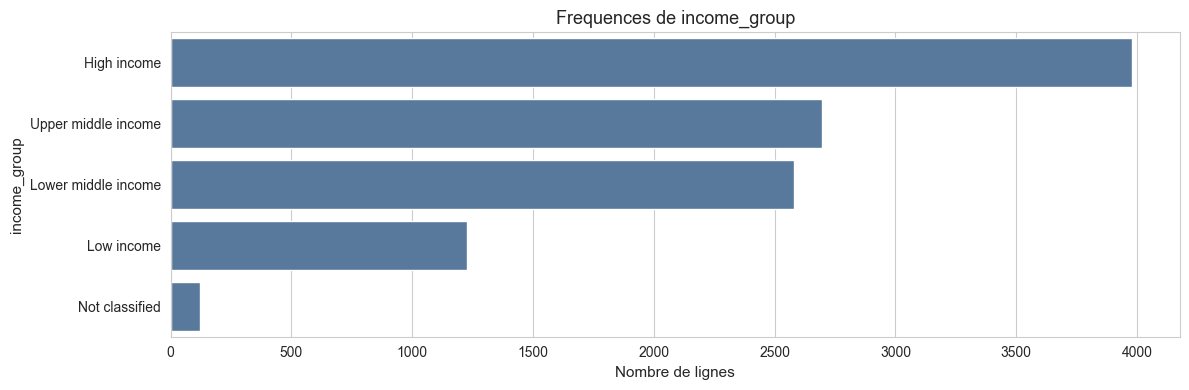

Modalites rares (< 1%) pour income_group:


,count,pct
income_group,,


Variable: lending_type


,count,pct
lending_type,,
IBRD,3371,31.792889
Not classified,3213,30.302745
IDA,2998,28.275017
Blend,1021,9.629350


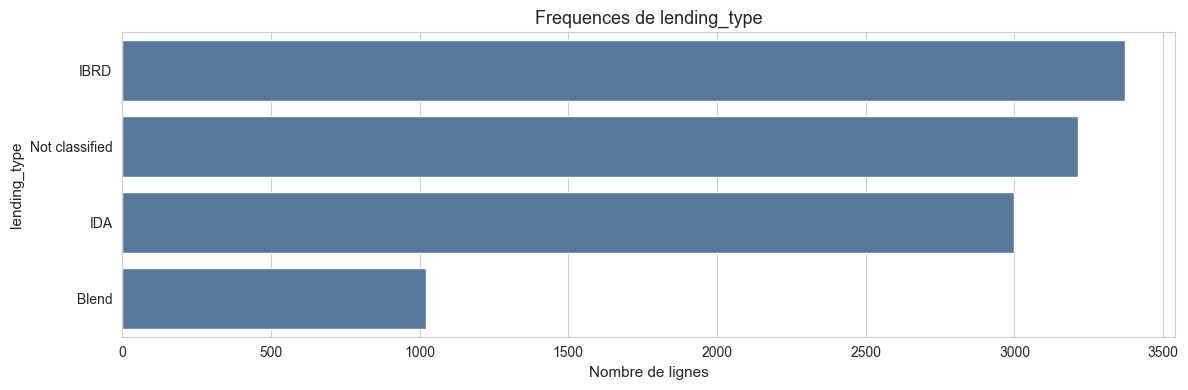

Modalites rares (< 1%) pour lending_type:


,count,pct
lending_type,,


Variable: is_crisis_decade


,count,pct
is_crisis_decade,,
2010s,2095,19.758559
2000s,2024,19.088937
1990s,1918,18.089220
1980s,1639,15.457889
1970s,1391,13.118929
1960s,907,8.554183
2020s,629,5.932283


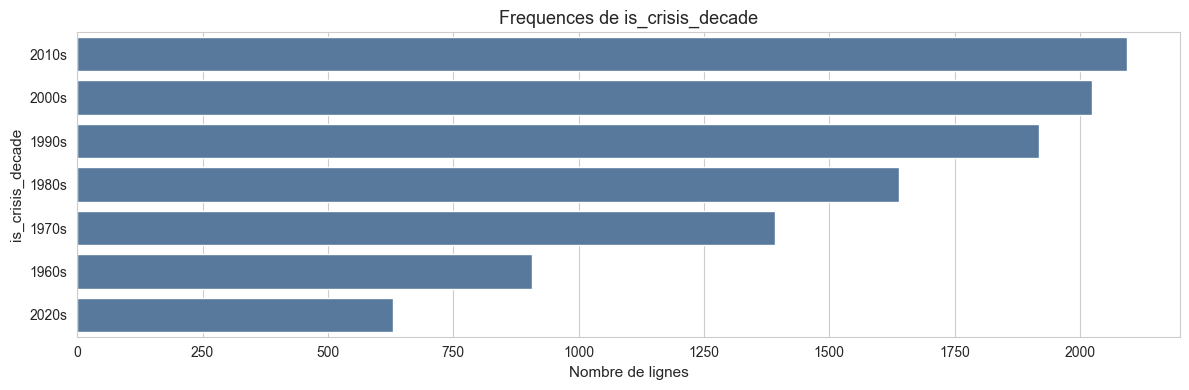

Modalites rares (< 1%) pour is_crisis_decade:


,count,pct
is_crisis_decade,,


In [20]:
# Frequences des variables categorielles et detection des modalites rares.
rare_modalities = {}

for col in categorical_vars:
    freq_table = (
        df[col]
        .value_counts(dropna=False)
        .rename('count')
        .to_frame()
    )
    freq_table['pct'] = 100 * freq_table['count'] / len(df)
    rare_modalities[col] = freq_table[freq_table['pct'] < 1]

    print(f'Variable: {col}')
    display(freq_table)

    plt.figure(figsize=(12, max(4, 0.35 * len(freq_table))))
    sns.barplot(x=freq_table['count'], y=freq_table.index.astype(str), color='#4c78a8')
    plt.title(f'Frequences de {col}')
    plt.xlabel('Nombre de lignes')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

    print(f'Modalites rares (< 1%) pour {col}:')
    display(rare_modalities[col])

### Notes apres execution

- Les variables categorielles decrivent principalement la region, le groupe de revenu, le type de pret et la decennie.
- Ces variables seront surtout utiles pour comparer les taux de choc par modalite dans l'analyse bivariee.
- Les modalites rares identifiees par les tableaux de frequences devront etre traitees avec prudence avant encodage.

## 6. Exploration bivariee: variables numeriques vs cible

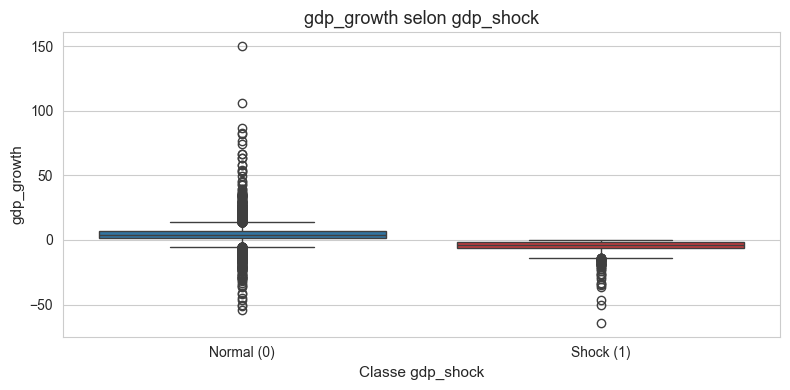

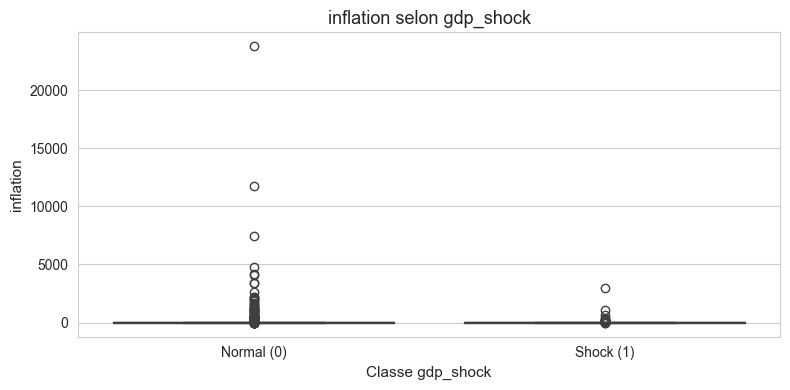

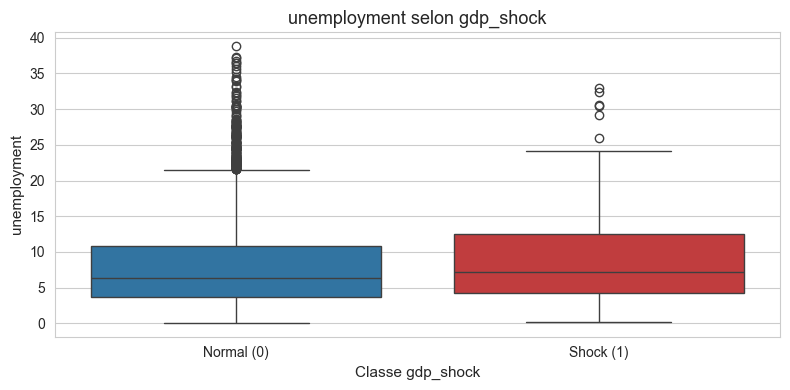

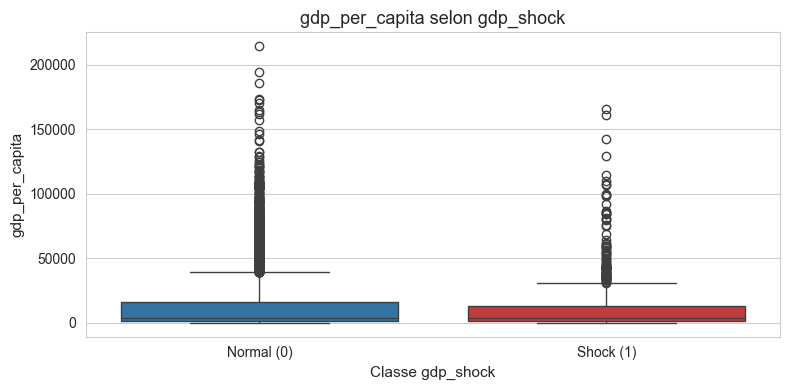

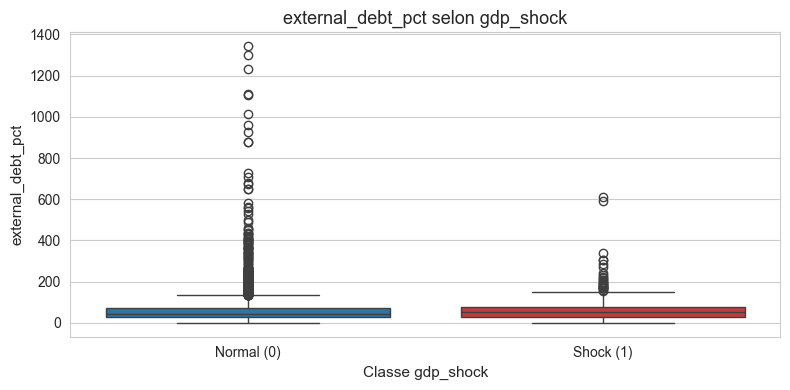

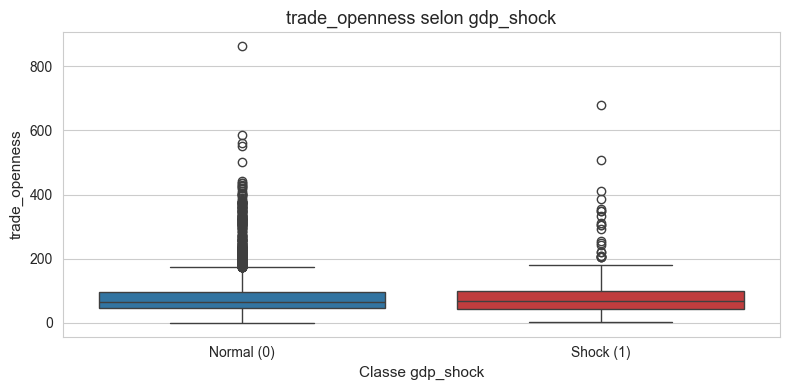

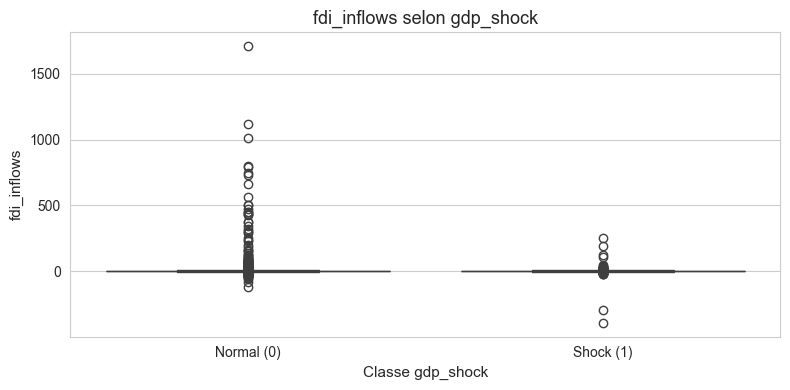

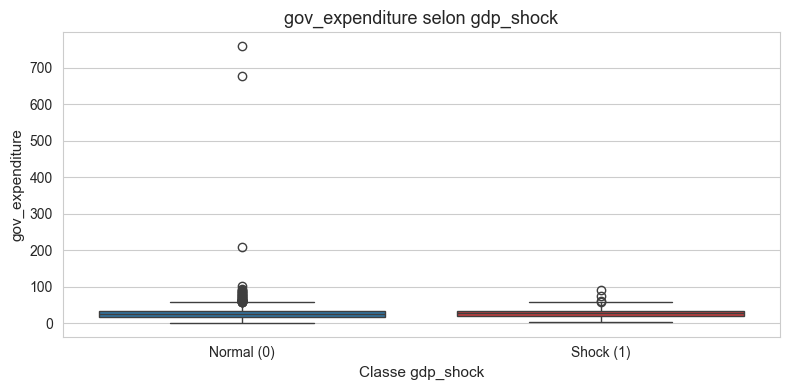

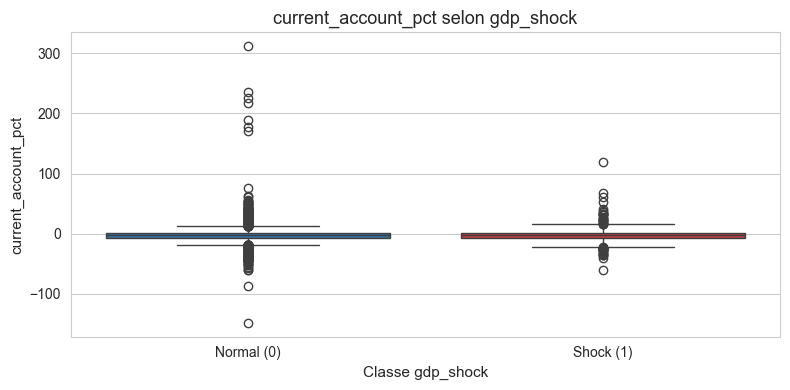

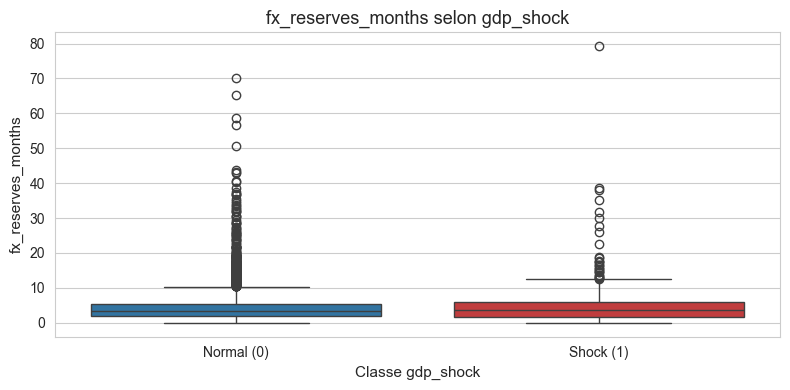

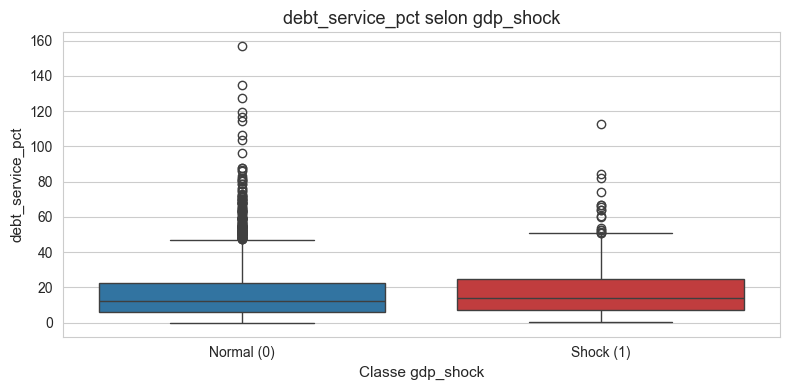

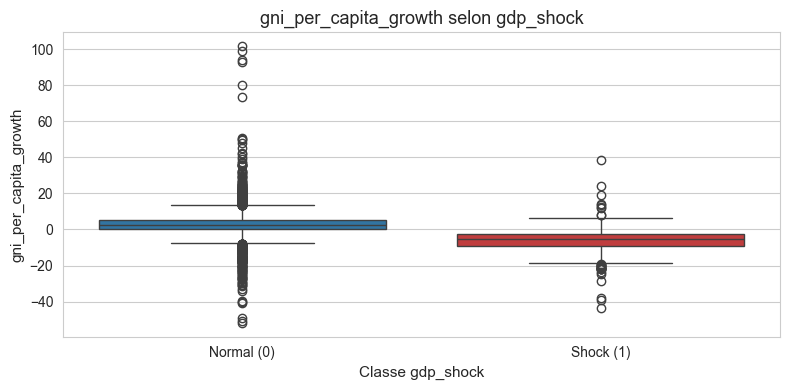

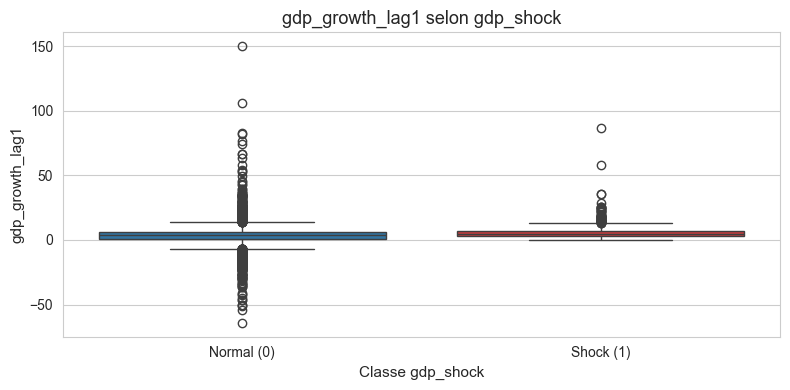

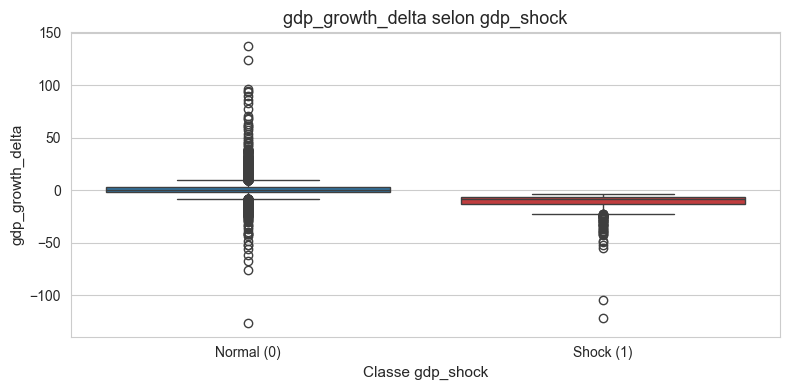

In [21]:
# Boxplots des variables numeriques par classe.
df_plot = df.copy()
df_plot['gdp_shock_label'] = df_plot[target].map(CLASS_LABELS)

for col in numeric_vars:
    plt.figure(figsize=(8, 4))
    sns.boxplot(
        data=df_plot,
        x='gdp_shock_label',
        y=col,
        hue='gdp_shock_label',
        palette=CLASS_LABEL_COLORS,
        legend=False
    )
    plt.title(f'{col} selon {target}')
    plt.xlabel('Classe gdp_shock')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [22]:
# Statistiques separees par classe pour les variables numeriques.
numeric_by_class = df.groupby(target)[numeric_vars].describe().T
display(numeric_by_class)

gdp_shock                         0           1
gdp_growth       count  9724.000000  879.000000
                 mean      4.441217   -5.092553
                 std       6.324614    5.651582
                 min     -54.402093  -64.047107
                 25%       1.900288   -6.548167
...                             ...         ...
gdp_growth_delta min    -126.198481 -121.864935
                 25%      -1.744065  -12.833999
                 50%       0.243541   -8.728942
                 75%       2.716096   -6.162958
                 max     137.165264   -4.007778

[112 rows x 2 columns]

In [23]:
# Comparaison des moyennes entre la classe 0 et la classe 1.
means_by_class = df.groupby(target)[numeric_vars].mean().T
means_by_class.columns = [CLASS_LABELS.get(c, c) for c in means_by_class.columns]

if CLASS_LABELS[0] in means_by_class.columns and CLASS_LABELS[1] in means_by_class.columns:
    means_by_class['difference_1_minus_0'] = means_by_class[CLASS_LABELS[1]] - means_by_class[CLASS_LABELS[0]]

display(means_by_class)

,Normal (0),Shock (1),difference_1_minus_0
gdp_growth,4.441217,-5.092553,-9.533771
inflation,23.589662,19.664135,-3.925527
unemployment,8.010306,8.903044,0.892738
gdp_per_capita,12508.681817,11702.548149,-806.133668
external_debt_pct,60.016600,65.110159,5.093559
trade_openness,77.734828,79.871402,2.136574
fdi_inflows,5.288739,2.448700,-2.840039
gov_expenditure,26.440280,29.030864,2.590584
current_account_pct,-2.780785,-2.552447,0.228338
fx_reserves_months,4.285163,4.925718,0.640554


In [ ]:
# Classement exploratoire par difference standardisee de moyenne.
# Ce n'est pas encore un modele predictif, seulement une mesure descriptive.
signal_rows = []

for col in numeric_vars:
    class_0 = df.loc[df[target] == 0, col].dropna()
    class_1 = df.loc[df[target] == 1, col].dropna()
    pooled_std = np.sqrt((class_0.var() + class_1.var()) / 2)
    standardized_diff = np.nan if pooled_std == 0 else (class_1.mean() - class_0.mean()) / pooled_std

    signal_rows.append({
        'feature': col,
        'mean_class_0': class_0.mean(),
        'mean_class_1': class_1.mean(),
        'standardized_mean_diff': standardized_diff,
        'abs_standardized_mean_diff': abs(standardized_diff)
    })

signal_features = pd.DataFrame(signal_rows).sort_values('abs_standardized_mean_diff', ascending=False)
display(signal_features)

### Notes apres execution

- Les variables qui separent le plus clairement les classes 0 et 1 sont `gdp_growth`, `gdp_growth_delta` et `gni_per_capita_growth`.
- Les differences standardisees de moyenne sont fortes pour `gdp_growth` (1.59 en valeur absolue), `gdp_growth_delta` (1.51) et `gni_per_capita_growth` (1.21). `gdp_growth_lag1` montre une separation plus faible (0.38).
- Les autres variables numeriques ont des differences standardisees plus faibles, toutes inferieures a 0.17 en valeur absolue dans ce tableau.
- Risque de fuite de donnees: `gdp_growth`, `gdp_growth_delta` et `gdp_growth_lag1` sont directement lies a la construction de `gdp_shock`. Les utiliser dans un modele peut produire des performances artificiellement elevees.

## 7. Exploration bivariee: variables categorielles vs cible

Variable: region


,0,1,shock_rate_pct
region,,,
Sub-Saharan Africa,2373,260,9.874668
"Middle East, North Africa, Afghanistan & Pakistan",1031,110,9.640666
East Asia & Pacific,1611,150,8.517888
Latin America & Caribbean,1919,171,8.181818
South Asia,322,23,6.666667
Europe & Central Asia,2295,155,6.326531
North America,173,10,5.464481


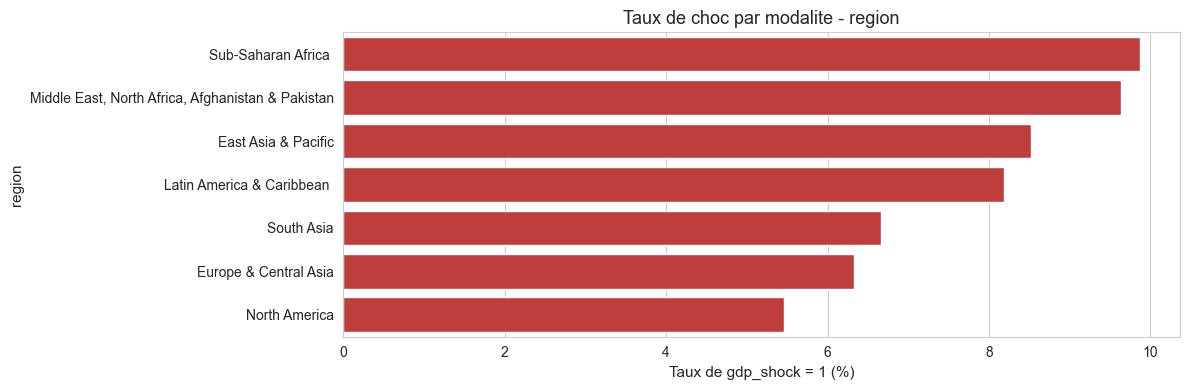

Variable: income_group


,0,1,shock_rate_pct
income_group,,,
Low income,1084,143,11.654442
Not classified,110,11,9.090909
Upper middle income,2455,241,8.939169
Lower middle income,2387,193,7.480620
High income,3688,291,7.313395


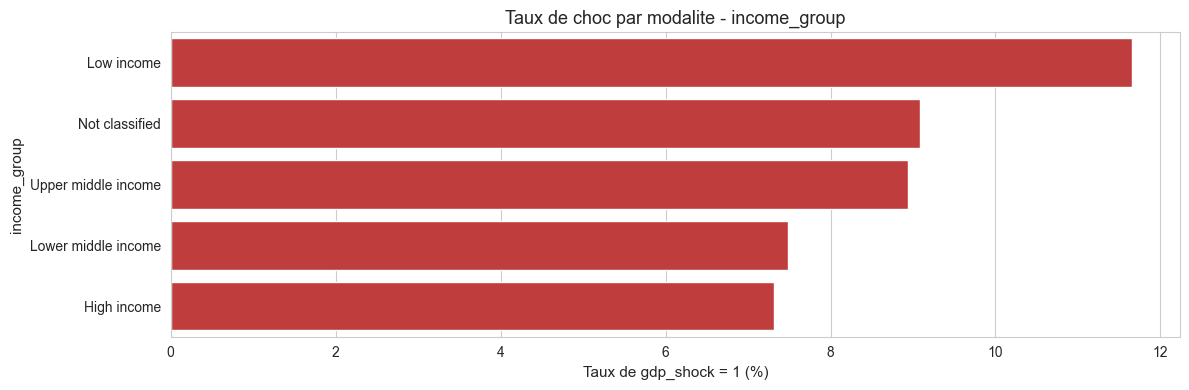

Variable: lending_type


,0,1,shock_rate_pct
lending_type,,,
IDA,2693,305,10.173449
Blend,933,88,8.619001
IBRD,3102,269,7.979828
Not classified,2996,217,6.753813


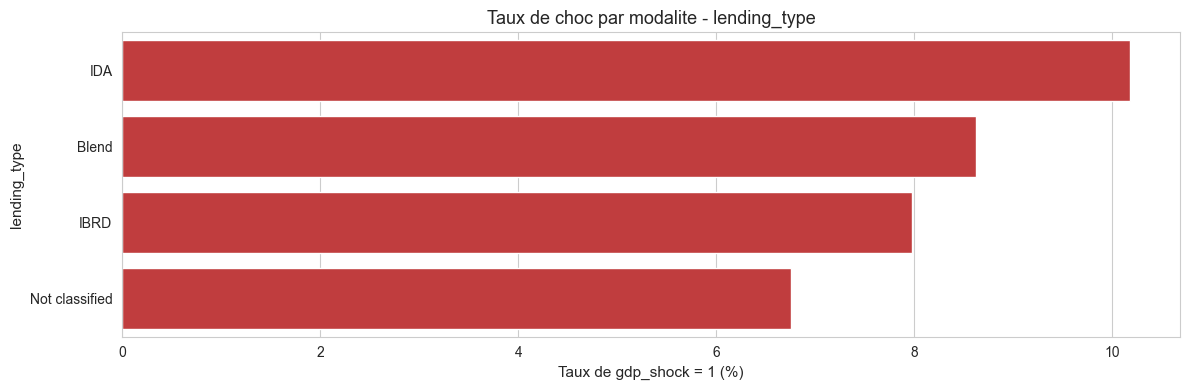

Variable: is_crisis_decade


,0,1,shock_rate_pct
is_crisis_decade,,,
2020s,486,143,22.734499
1980s,1465,174,10.616229
1970s,1269,122,8.770669
2000s,1871,153,7.559289
1990s,1776,142,7.403545
1960s,847,60,6.615215
2010s,2010,85,4.057279


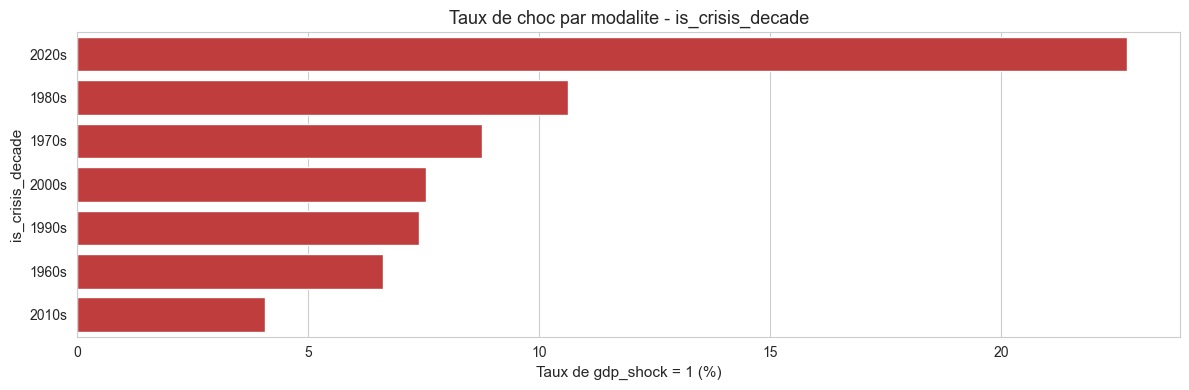

In [24]:
# Tables croisees et taux de classe positive par modalite.
categorical_target_tables = {}

for col in categorical_vars:
    crosstab = pd.crosstab(df[col], df[target], dropna=False)
    positive_rate = (df.groupby(col, dropna=False)[target].mean() * 100).rename('shock_rate_pct')
    combined = crosstab.join(positive_rate).sort_values('shock_rate_pct', ascending=False)
    categorical_target_tables[col] = combined

    print(f'Variable: {col}')
    display(combined)

    plt.figure(figsize=(12, max(4, 0.35 * len(combined))))
    sns.barplot(x=combined['shock_rate_pct'], y=combined.index.astype(str), color='#d62728')
    plt.title(f'Taux de choc par modalite - {col}')
    plt.xlabel('Taux de gdp_shock = 1 (%)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Notes apres execution

- Le taux de choc varie selon les decennies. Les annees 2020 ont le taux le plus eleve (22.7%), devant les annees 1980 (10.6%) et 1970 (8.8%).
- Par region, les taux les plus eleves sont observes en Afrique subsaharienne (9.9%) et au Moyen-Orient, Afrique du Nord, Afghanistan & Pakistan (9.6%). Le taux le plus faible est observe en Amerique du Nord (5.5%).
- Par groupe de revenu, le taux le plus eleve concerne les pays a faible revenu (11.7%). Les groupes `High income`, `Lower middle income` et `Upper middle income` ont des taux compris entre 7.3% et 8.9%.

## 8. Correlations entre variables numeriques

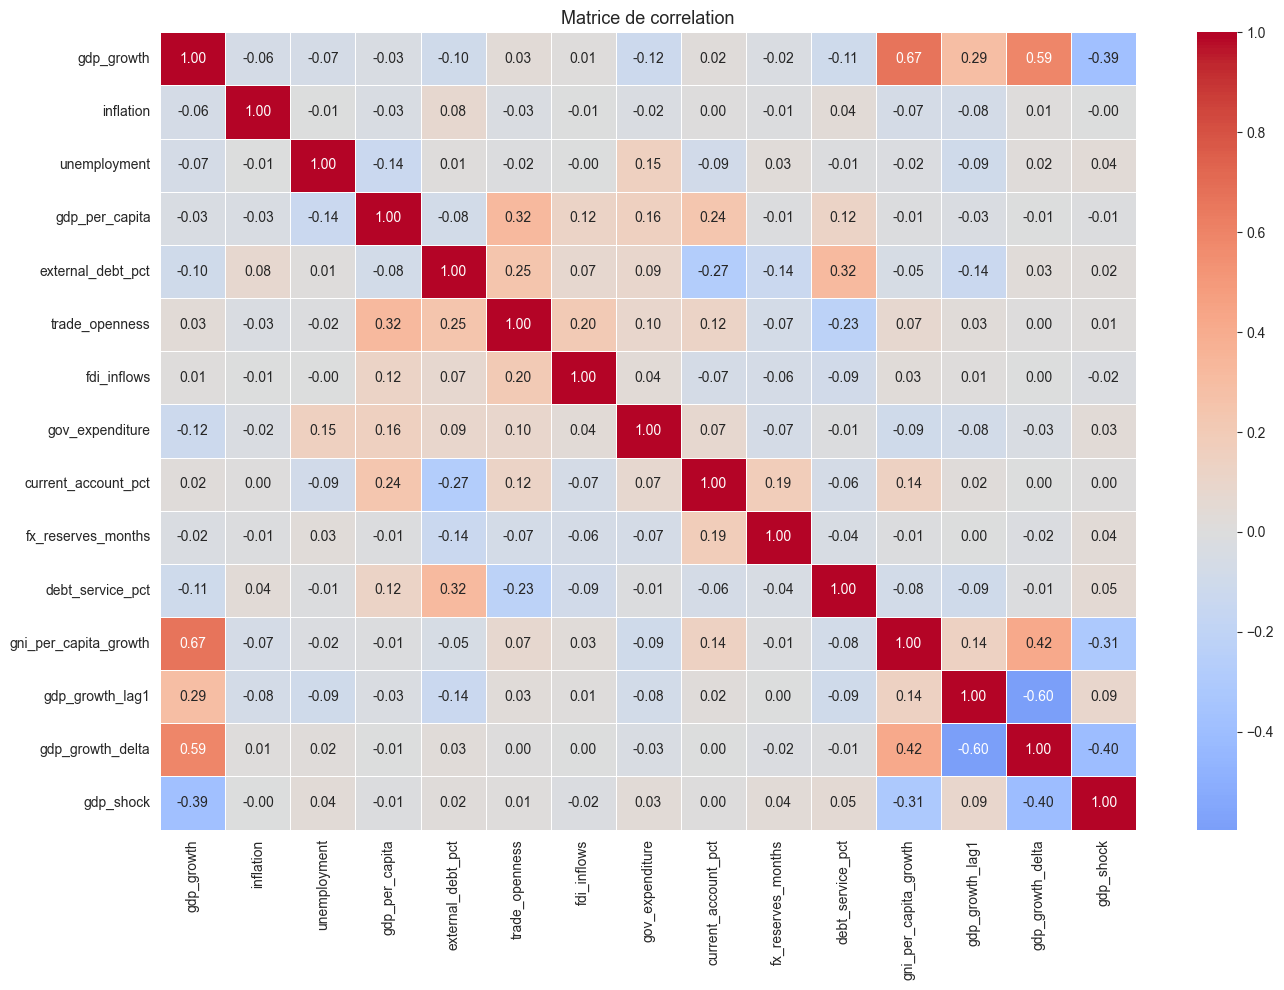

,corr_with_gdp_shock
gdp_growth_delta,-0.404891
gdp_growth,-0.386600
gni_per_capita_growth,-0.310535
gdp_growth_lag1,0.094827
debt_service_pct,0.047525
unemployment,0.038135
fx_reserves_months,0.038035
gov_expenditure,0.034644
fdi_inflows,-0.021279
external_debt_pct,0.018788


In [25]:
# Matrice de correlation incluant les variables numeriques et la cible.
corr_cols = numeric_vars + [target]
corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Matrice de correlation')
plt.tight_layout()
plt.show()

target_corr = corr_matrix[target].drop(target).sort_values(key=lambda s: s.abs(), ascending=False)
display(target_corr.rename('corr_with_gdp_shock').to_frame())

In [26]:
# Paires de variables numeriques fortement correlees entre elles.
corr_abs = corr_matrix.drop(index=target, columns=target).abs()
upper_mask = np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
strong_pairs = (
    corr_abs.where(upper_mask)
    .stack()
    .rename('abs_corr')
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
    .query('abs_corr >= 0.70')
    .sort_values('abs_corr', ascending=False)
)

display(strong_pairs)

,feature_1,feature_2,abs_corr


### Notes apres execution

- Aucune paire de variables explicatives n'a une correlation forte superieure ou egale a 0.70 en valeur absolue.
- Les plus fortes correlations avec `gdp_shock` sont: `gdp_growth_delta` (-0.40), `gdp_growth` (-0.39), `gni_per_capita_growth` (-0.31), puis `gdp_growth_lag1` (0.09).
- Toutes les autres variables numeriques ont une correlation inferieure a 0.05 en valeur absolue avec `gdp_shock`.
- Les correlations les plus elevees concernent des variables liees a la croissance du PIB. `gdp_growth`, `gdp_growth_delta` et `gdp_growth_lag1` doivent donc etre signalees comme variables a risque de fuite de donnees.

## 9. Synthese finale apres exploration

### Synthese finale

- **Variables fortement liees a `gdp_shock`:** `gdp_growth_delta` (-0.40), `gdp_growth` (-0.39) et `gdp_growth_lag1` (0.09) sont liees a la construction de la cible. Leur correlation elevee nest pas un signal predictif exploitable: cest un signal dalerte de fuite de donnees.
- **Decision de leakage:** `gdp_growth`, `gdp_growth_delta` et `gdp_growth_lag1` seront supprimees de la matrice de features. Les conserver permettrait au modele de retrouver la formule de labellisation de `gdp_shock`, au lieu dapprendre des relations economiques generalisables.
- **Signal economique restant:** apres retrait des variables qui definissent directement la cible, les autres variables numeriques presentent des relations beaucoup plus faibles avec `gdp_shock`, a lexception de `gni_per_capita_growth` qui reste un signal de croissance macroeconomique mais ne fait pas partie de la formule exacte du label.
- **Problemes de qualite des donnees:** plusieurs variables ont beaucoup de valeurs manquantes, notamment `domestic_credit_pct` (86.75%), `govt_debt_pct_gdp` (85.16%), `gov_expenditure` (59.00%), `debt_service_pct` (57.49%) et `external_debt_pct` (50.58%). La classe positive est rare: 8.3% contre 91.7% pour la classe normale.
- **Valeurs extremes:** `current_account_pct` varie environ de -148 a +312 et `gdp_growth_delta` de -126 a +137. Ces valeurs sont identifiees comme reelles, pas comme des erreurs.
- **Risques methodologiques:** le principal risque identifie est maintenant traite par la suppression des variables de croissance du PIB utilisees pour creer la cible. Le pic des annees 2020 (22.7% de chocs) doit aussi etre pris en compte dans la validation temporelle.
- **Decisions avant modelisation:** construire le pipeline final avec imputation train-only, encodage, scaling robuste, traitement du desequilibre de classes et evaluation par recall, precision, F1 et PR-AUC.
